In [110]:
import pandas as pd
import matplotlib.pyplot as plt
import plotly.express as px

# Load your dataset
df = pd.read_csv('gurgaon_properties_post_feature_selection_v2.csv')

In [104]:
df.shape

(3670, 13)

In [105]:
df.head(2)

,property_type,sector,price,bedRoom,bathroom,balcony,agePossession,built_up_area,servant room,store room,furnishing_type,luxury_category,floor_category
0,flat,sector 36,0.82,3,2,2,New Property,850.0,0,0,0,Low,Low floor
1,flat,sector 89,0.95,2,2,2,New Property,1226.0,1,0,0,Low,Mid floor


In [20]:
!pip install pandas geopy tqdm plotly

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2/2 [geopy]


In [3]:
import pandas as pd
from geopy.geocoders import Nominatim
from geopy.extra.rate_limiter import RateLimiter
from tqdm import tqdm
import time

# Load dataset
file_path = "gurgaon_properties_post_feature_selection_v2.csv"
df = pd.read_csv(file_path)

# Get unique sectors
unique_sectors = df['sector'].dropna().unique()

# Initialize geocoder
geolocator = Nominatim(user_agent="gurgaon_real_estate_project")
geocode = RateLimiter(geolocator.geocode, min_delay_seconds=1)

# Function to get coordinates
sector_coordinates = []

for sector in tqdm(unique_sectors):
    try:
        # Improve search accuracy
        query = f"{sector}, Gurgaon, Haryana, India"

        location = geocode(query)

        if location:
            sector_coordinates.append({
                'sector': sector,
                'latitude': location.latitude,
                'longitude': location.longitude
            })
        else:
            sector_coordinates.append({
                'sector': sector,
                'latitude': None,
                'longitude': None
            })

    except Exception as e:
        print(f"Error for {sector}: {e}")
        sector_coordinates.append({
            'sector': sector,
            'latitude': None,
            'longitude': None
        })

# Create coordinates dataframe
coords_df = pd.DataFrame(sector_coordinates)

# Save coordinates separately
coords_df.to_csv("sector_coordinates.csv", index=False)

# Merge back into original dataset
final_df = df.merge(coords_df, on='sector', how='left')

# Save updated dataset
final_df.to_csv("gurgaon_properties_with_coordinates.csv", index=False)

print("Done! Coordinates added successfully.")

100%|█████████████████████████████████████████████████████████████████████████████████| 104/104 [01:51<00:00,  1.07s/it]

Done! Coordinates added successfully.


In [4]:
final_df.shape

(3670, 15)

In [5]:
final_df.head()

,property_type,sector,price,bedRoom,bathroom,balcony,agePossession,built_up_area,servant room,store room,furnishing_type,luxury_category,floor_category,latitude,longitude
0,flat,sector 36,0.82,3,2,2,New Property,850.0,0,0,0,Low,Low floor,28.419334,76.988926
1,flat,sector 89,0.95,2,2,2,New Property,1226.0,1,0,0,Low,Mid floor,28.418446,76.945757
2,flat,sohna road,0.32,2,2,1,New Property,1000.0,0,0,0,Low,High floor,28.394656,77.046643
3,flat,sector 92,1.60,3,4,3+,Relatively New,1615.0,1,0,1,High,Mid floor,28.408905,76.915523
4,flat,sector 102,0.48,2,2,1,Relatively New,582.0,0,1,0,High,Mid floor,28.475487,76.971175


In [87]:
lat_long_df = final_df.groupby('sector')[['price','built_up_area','latitude','longitude']].mean()

In [88]:
lat_long_df.to_csv("lat_long_df.csv")

/var/folders/77/wyg5lhbd4cb16lv4yrxznbf00000gn/T/ipykernel_1785/354887685.py:1: DeprecationWarning:

*scatter_mapbox* is deprecated! Use *scatter_map* instead. Learn more at: https://plotly.com/python/mapbox-to-maplibre/



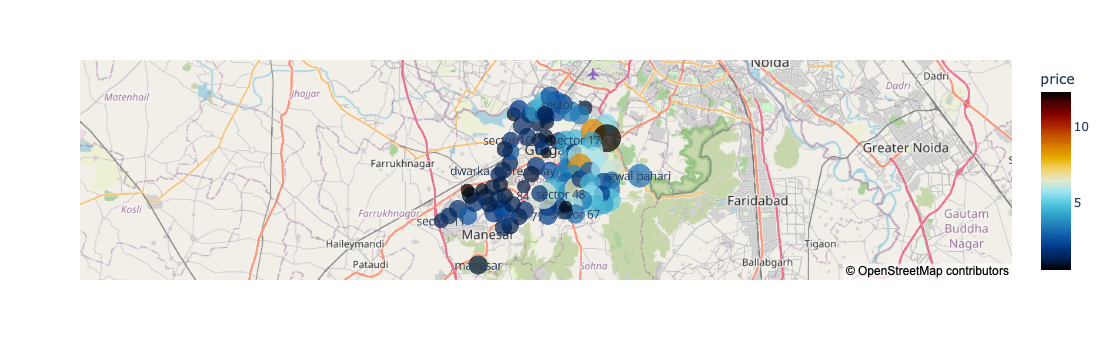

In [132]:
fig = px.scatter_mapbox(group_df, lat="latitude", lon="longitude", color="price", size='built_up_area',
                  color_continuous_scale=px.colors.cyclical.IceFire, zoom=9,
                  mapbox_style="open-street-map",text=group_df.index)
fig.show()

In [89]:
df2 = pd.read_csv('gurgaon_properties_cleaned_v1.csv')

In [90]:
df2.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3803 entries, 0 to 3802
Data columns (total 17 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   property_type    3803 non-null   object 
 1   society          3802 non-null   object 
 2   sector           3803 non-null   object 
 3   price            3785 non-null   float64
 4   price_per_sqft   3785 non-null   float64
 5   areaWithType     3803 non-null   object 
 6   bedRoom          3803 non-null   int64  
 7   bathroom         3803 non-null   int64  
 8   balcony          3803 non-null   object 
 9   additionalRoom   3803 non-null   object 
 10  noOfFloor        3784 non-null   float64
 11  facing           2698 non-null   object 
 12  agePossession    3802 non-null   object 
 13  nearbyLocations  3626 non-null   object 
 14  furnishDetails   2822 non-null   object 
 15  features         3168 non-null   object 
 16  area_sqft        3785 non-null   float64
dtypes: float64(4),

In [ ]:
merged_df = df2.merge(df, left_index=True, right_index=True, suffixes=('_df2', '_df1'))

In [92]:
merged_df['sector'] = merged_df['sector_df2'].fillna(merged_df['sector_df1'])

In [66]:
df3 = merged_df.dropna(subset=['furnishDetails'])

In [68]:
df3.to_csv('world_cloud.csv',index=False)

In [77]:
import pandas as pd
import ast

def process_furnishing_data(df):
    # Dictionary to store aggregated items: {sector: [flat_list_of_details]}
    sector_summary = {}

    # We iterate through each row as requested
    for index, row in df.iterrows():
        sector = row['sector']
        # Converting the string representation of the list into a real Python list
        try:
            raw_details = ast.literal_eval(row['furnishDetails']) if isinstance(row['furnishDetails'], str) else []
        except:
            raw_details = []

        # Filter out "No ..." items to keep only existing furniture
        cleaned_details = [item for item in raw_details if not item.startswith('No ')]

        if sector not in sector_summary:
            sector_summary[sector] = []
        
        # 'extend' adds items to the list individually, keeping it as a "single list" 
        # instead of a list of lists.
        sector_summary[sector].extend(cleaned_details)

    # Convert the dictionary into a new DataFrame
    # We use set() or dict.fromkeys() to remove duplicates if the same item appears multiple times in a sector
    processed_data = []
    for sector, details in sector_summary.items():
        unique_details = list(dict.fromkeys(details)) # Removes duplicates while keeping order
        processed_data.append({'sector': sector, 'furnishDetail': unique_details})

    return pd.DataFrame(processed_data)

# Load your dataset
df = pd.read_csv('world_cloud.csv')

# Create the new dataset
new_df = process_furnishing_data(df)

# Display the result
print(new_df.head())

             sector                                      furnishDetail
0  sector 3 phase 2  [2 Wardrobe, 1 Water Purifier, 5 Fan, 1 Geyser...
1         sector 56  [5 Fan, 1 Exhaust Fan, 3 Geyser, 25 Light, 1 C...
2        sector 102  [3 Wardrobe, 5 Fan, 1 Exhaust Fan, 1 Geyser, 1...
3         sector 49  [22 Wardrobe, 24 Fan, 1 Exhaust Fan, 33 Light,...
4         sector 86  [3 Wardrobe, 5 Fan, 1 Exhaust Fan, 3 Geyser, 1...


In [82]:
def list_to_string(item):
    return ", ".join(item)

In [84]:
new_df['furnishDetail'] = new_df['furnishDetail'].apply(list_to_string)

In [85]:
new_df.head()

,sector,furnishDetail
0,sector 3 phase 2,"2 Wardrobe, 1 Water Purifier, 5 Fan, 1 Geyser,..."
1,sector 56,"5 Fan, 1 Exhaust Fan, 3 Geyser, 25 Light, 1 Ch..."
2,sector 102,"3 Wardrobe, 5 Fan, 1 Exhaust Fan, 1 Geyser, 1 ..."
3,sector 49,"22 Wardrobe, 24 Fan, 1 Exhaust Fan, 33 Light, ..."
4,sector 86,"3 Wardrobe, 5 Fan, 1 Exhaust Fan, 3 Geyser, 10..."


In [86]:
new_df.to_csv('WordCloudFinal.csv')

In [97]:
new_df[new_df['sector'] == 'sector 56']['furnishDetail'].to_string()

'1    5 Fan, 1 Exhaust Fan, 3 Geyser, 25 Light, 1 Ch...'

In [118]:
df.sample(5)

,property_type,sector,price,bedRoom,bathroom,balcony,agePossession,built_up_area,servant room,store room,furnishing_type,luxury_category,floor_category
463,flat,sector 53,6.44,4,4,3,Moderately Old,3068.0,1,0,1,Medium,Mid floor
2174,flat,sector 33,1.07,2,2,2,Under Construction,1253.0,0,0,0,Medium,High floor
650,house,sector 2,5.20,4,5,2,Moderately Old,5200.0,0,0,0,Low,Low floor
347,house,sector 14,6.40,6,6,3+,Old Property,3150.0,0,0,0,Low,Mid floor
1391,flat,sector 78,1.15,3,3,3,Moderately Old,1969.0,1,0,0,Low,Mid floor


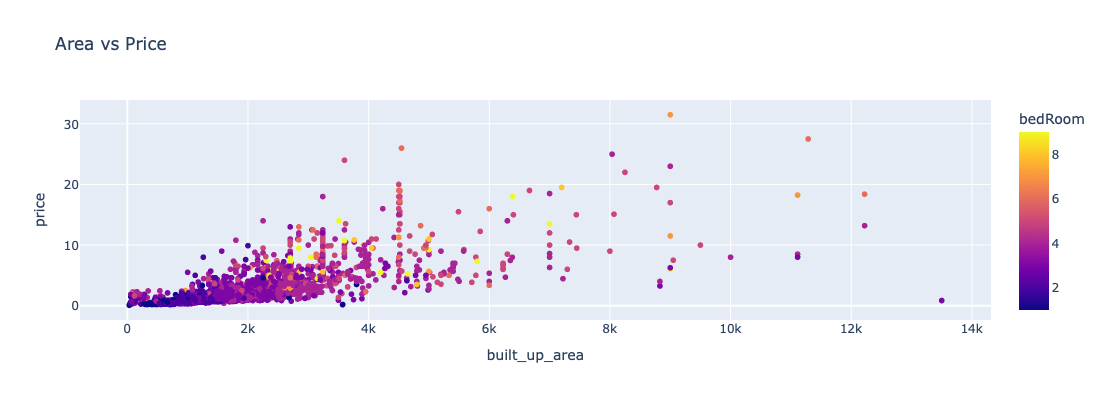

In [116]:
fig = px.scatter(df,x=df['built_up_area'],y=df['price'],color='bedRoom',title='Area vs Price',width=800,height=400)

fig.show()

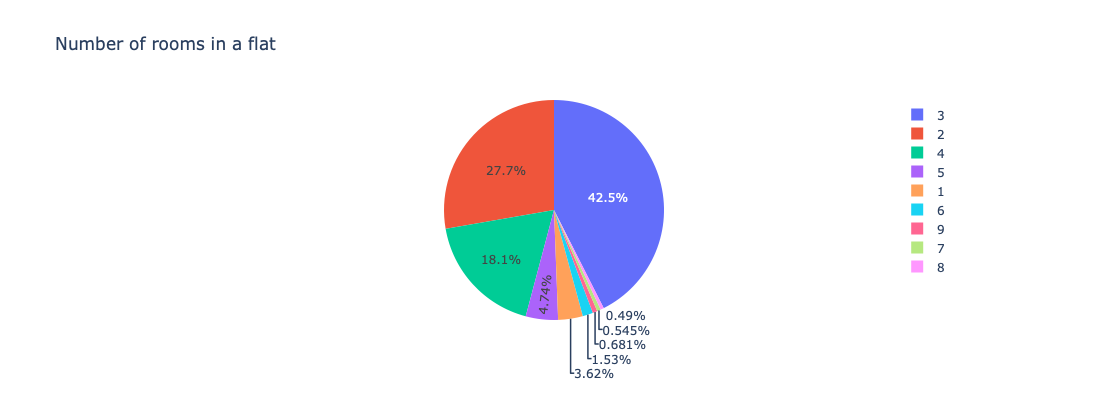

In [127]:
fig2 = px.pie(df, names = df['bedRoom'], title = 'Number of rooms in a flat',width = 600,height=400)
fig2.show()

In [129]:
option = df['sector'].unique().tolist()

In [130]:
option.insert(0,'Overall')

In [131]:
option

['Overall',
 'sector 36',
 'sector 89',
 'sohna road',
 'sector 92',
 'sector 102',
 'gwal pahari',
 'sector 108',
 'sector 105',
 'sector 26',
 'sector 109',
 'sector 28',
 'sector 65',
 'sector 12',
 'sector 85',
 'sector 70a',
 'sector 30',
 'sector 107',
 'sector 3',
 'sector 2',
 'sector 41',
 'sector 4',
 'sector 62',
 'sector 49',
 'sector 81',
 'sector 66',
 'sector 86',
 'sector 48',
 'sector 51',
 'sector 37',
 'sector 111',
 'sector 67',
 'sector 113',
 'sector 61',
 'sector 69',
 'sector 67a',
 'sector 37d',
 'sector 82',
 'sector 53',
 'sector 74',
 'sector 52',
 'sector 43',
 'sector 14',
 'sector 25',
 'sector 95',
 'sector 56',
 'sector 83',
 'sector 104',
 'sector 88a',
 'sector 55',
 'sector 50',
 'sector 84',
 'sector 91',
 'sector 76',
 'sector 82a',
 'sector 78',
 'manesar',
 'sector 93',
 'sector 7',
 'sector 71',
 'sector 110',
 'sector 33',
 'sector 70',
 'sector 103',
 'sector 90',
 'sector 38',
 'sector 79',
 'sector 112',
 'sector 22',
 'sector 59',
 'sector 